In [28]:
import pandas as pd
import calliope as cp
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
output_file = "model_results_pypsa_base.nc" #use output file

model = cp.read_netcdf(output_file)

print("Model results reloaded from file")

Model results reloaded from file


In [29]:
generation = model.results.carrier_prod

technologies = [label.split("::")[1] for label in generation.loc_tech_carriers_prod.values]
generation = generation.assign_coords(techs=('loc_tech_carriers_prod', technologies))

# Include only the relevant technologies
included_techs = [
    "bss_liion", "pp_biomass_standalone", "pp_ccgt_gas", 
    "pp_nuclear_gen3", "pv_rooftop", "pv_utility", 
    "wind_offshore", "wind_onshore", "pp_hard_coal"
]
generation = generation.sel(
    loc_tech_carriers_prod=[tech in included_techs for tech in generation.techs.values]
)
# Step 1: Extract the technologies and filter for renewables
renewable_techs = ["pv_rooftop", "pv_utility", "wind_offshore", "wind_onshore"]

# Filter the generation data for renewable technologies
renewable_generation = generation.sel(
    loc_tech_carriers_prod=[tech in renewable_techs for tech in generation.techs.values]
)

# Step 2: Sum the renewable generation across all locations and technologies for each timestep
total_renewable_generation = renewable_generation.sum(dim="loc_tech_carriers_prod")

# Step 3: Find the timestep with the maximum renewable generation
max_hour_idx = total_renewable_generation.argmax(dim="timesteps")
max_hour = total_renewable_generation.timesteps[max_hour_idx].values
max_value = total_renewable_generation[max_hour_idx].values

# Output the hour with the highest renewable generation and the generation amount
print(f"The hour with the highest renewable generation is: {max_hour}")
print(f"Total renewable generation during this hour: {max_value} GW")


The hour with the highest renewable generation is: 2050-06-08T13:00:00.000000000
Total renewable generation during this hour: 24.6509171474541 GW


In [30]:
df1=df = pd.read_csv("net_flow_pypsa.csv")
df2=df = pd.read_csv("net_flow_tennet.csv")
filtered_df1 = df1.loc[(df1['timesteps'] == "2050-06-08 13:00:00")]
filtered_df2 = df2.loc[(df2['timesteps'] == "2050-06-08 13:00:00")]

In [31]:
filtered_df1

,loc_tech_carriers,timesteps,net_flow
3805,DE::transmission_hvac:NL42::electricity,2050-06-08 13:00:00,1.631855
12565,NL33::transmission_hvdc:UK::electricity,2050-06-08 13:00:00,-0.999987
21325,NL12::transmission_hvac:NL11::electricity,2050-06-08 13:00:00,-0.411673
30085,NL13::transmission_hvac:NL11::electricity,2050-06-08 13:00:00,-0.926891
38845,NL13::transmission_hvac:NL21::electricity,2050-06-08 13:00:00,0.537914
47605,DK::transmission_hvdc:NL11::electricity,2050-06-08 13:00:00,0.699992
56365,NL42::transmission_hvac:DE::electricity,2050-06-08 13:00:00,-1.631855
65125,NL11::transmission_hvdc:DK::electricity,2050-06-08 13:00:00,-0.699992
73885,NL41::transmission_hvac:NL34::electricity,2050-06-08 13:00:00,2.113705
82645,NL42::transmission_hvac:BE::electricity,2050-06-08 13:00:00,-1.171054


In [40]:
df1 = filtered_df1.copy()

# Function to extract and sort the location pair
def extract_pairs(loc_tech):
    parts = loc_tech.split("::")
    location1 = parts[0]
    location2 = parts[1].split(":")[1]  
    return tuple(sorted([location1, location2]))  

# Add the location pairs column
df1["pairs"] = df1["loc_tech_carriers"].apply(extract_pairs)

# Find the rows with the maximum absolute carrier_prod for each pair
result = (
    df1.loc[df1.groupby("pairs")["net_flow"].apply(lambda x: x.abs().idxmax())]
    .reset_index(drop=True)  # Reset index for clarity
)

print(result)


                            loc_tech_carriers            timesteps  net_flow  \
0     BE::transmission_hvac:NL34::electricity  2050-06-08 13:00:00  2.228921   
1     NL42::transmission_hvac:BE::electricity  2050-06-08 13:00:00 -1.171054   
2     NL11::transmission_hvac:DE::electricity  2050-06-08 13:00:00 -1.324718   
3     NL21::transmission_hvac:DE::electricity  2050-06-08 13:00:00 -1.554494   
4     DE::transmission_hvac:NL22::electricity  2050-06-08 13:00:00  1.488921   
5     DE::transmission_hvac:NL42::electricity  2050-06-08 13:00:00  1.631855   
6     DK::transmission_hvdc:NL11::electricity  2050-06-08 13:00:00  0.699992   
7   NL12::transmission_hvac:NL11::electricity  2050-06-08 13:00:00 -0.411673   
8   NL13::transmission_hvac:NL11::electricity  2050-06-08 13:00:00 -0.926891   
9     NO::transmission_hvdc:NL11::electricity  2050-06-08 13:00:00  0.699978   
10  NL23::transmission_hvac:NL12::electricity  2050-06-08 13:00:00  0.220449   
11  NL13::transmission_hvac:NL21::electr

In [41]:
df2 = filtered_df2.copy()

# Function to extract and sort the location pair
def extract_pairs(loc_tech):
    parts = loc_tech.split("::")
    location1 = parts[0]
    location2 = parts[1].split(":")[1]  
    return tuple(sorted([location1, location2]))  

# Add the location pairs column
df2["pair"] = df2["loc_tech_carriers"].apply(extract_pairs)

# Find the rows with the maximum absolute carrier_prod for each pair
results = (
    df2.loc[df2.groupby("pair")["net_flow"].apply(lambda x: x.abs().idxmax())]
    .reset_index(drop=True)  # Reset index for clarity
)

print(results)


                            loc_tech_carriers            timesteps  net_flow  \
0     NL34::transmission_hvac:BE::electricity  2050-06-08 13:00:00 -2.183757   
1     BE::transmission_hvac:NL42::electricity  2050-06-08 13:00:00  1.216224   
2     NL11::transmission_hvac:DE::electricity  2050-06-08 13:00:00 -0.796660   
3     DE::transmission_hvac:NL21::electricity  2050-06-08 13:00:00  1.552747   
4     NL22::transmission_hvac:DE::electricity  2050-06-08 13:00:00 -2.070793   
5     NL42::transmission_hvac:DE::electricity  2050-06-08 13:00:00 -1.579789   
6     DK::transmission_hvdc:NL11::electricity  2050-06-08 13:00:00  0.699992   
7   NL12::transmission_hvac:NL11::electricity  2050-06-08 13:00:00 -0.652890   
8   NL13::transmission_hvac:NL11::electricity  2050-06-08 13:00:00 -0.158760   
9     NO::transmission_hvdc:NL11::electricity  2050-06-08 13:00:00  0.699984   
10  NL12::transmission_hvac:NL23::electricity  2050-06-08 13:00:00  0.012654   
11  NL13::transmission_hvac:NL21::electr

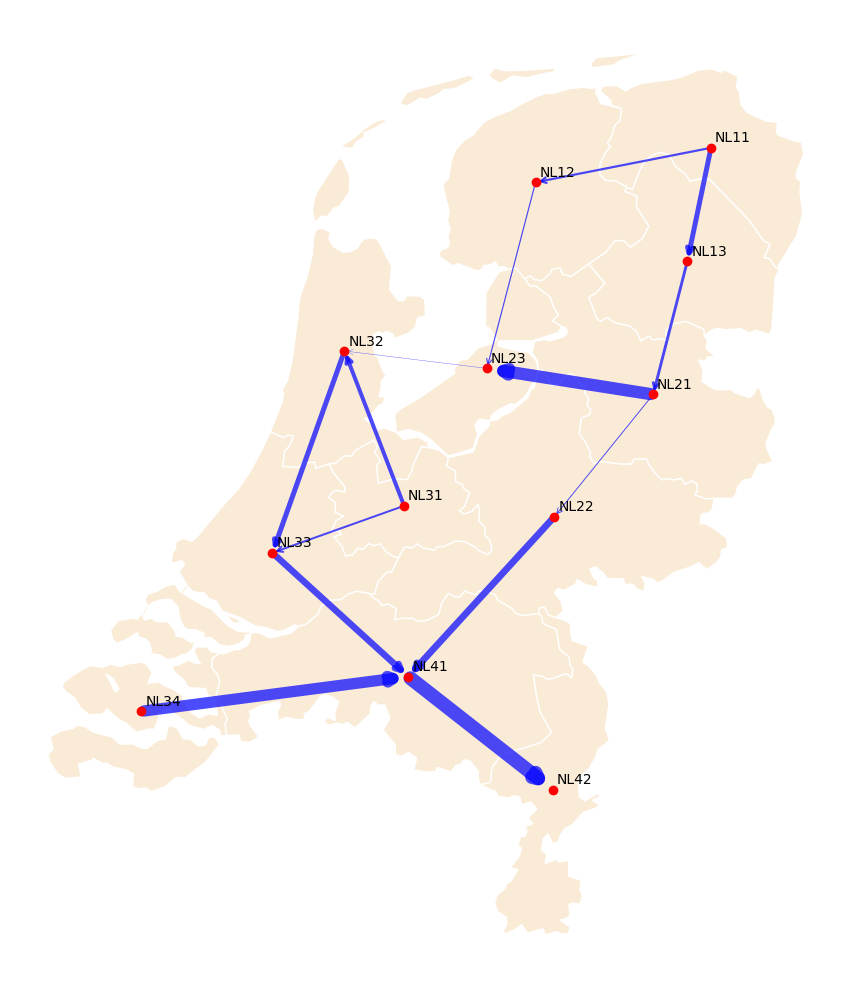

In [42]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

# Load the geojson file for the base map
geojson_file = "timeseries_data/demand/historic_2023/NUTS_RG_20M_2024_3035_modified.geojson"
gdf_base = gpd.read_file(geojson_file)

# Maximum net_flow for scaling
max_net_flow = result["net_flow"].abs().max()

# Extract node coordinates from the model
node_coords = pd.DataFrame(
    model.inputs['loc_coordinates'].values.T, 
    index=model.inputs['locs'].values, 
    columns=['lon', 'lat']
)

# Swap 'lat' and 'lon' to correct the coordinates
node_coords = node_coords.rename(columns={"lat": "lon", "lon": "lat"})[["lat", "lon"]]

# Exclude NL and NO nodes (adjust as needed)
excluded_nodes = ["NL","UK","NO","DK","DE","BE"]
node_coords = node_coords[~node_coords.index.isin(excluded_nodes)]

# Build a list of (start_loc, end_loc, flow_value)
parsed_links = []
for _, row in result.iterrows():
    loc_a, loc_b = row["pairs"]  
    net_flow = row["net_flow"]

    # Skip links involving excluded nodes
    if (loc_a in excluded_nodes) or (loc_b in excluded_nodes):
        continue

    # If net_flow > 0, direction = loc_b -> loc_a
    if net_flow > 0:
        parsed_links.append((loc_a, loc_b, net_flow))
    # If net_flow < 0, direction = loc_a -> loc_b (store it as a positive number for plotting)
    elif net_flow < 0:
        parsed_links.append((loc_a, loc_b, net_flow))
    # If net_flow == 0, we can still store (loc_b, loc_a, 0) for the thin black line
    else:
        parsed_links.append((loc_a, loc_b, 0))

# Create the plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the base map
gdf_base.plot(ax=ax, facecolor='antiquewhite', edgecolor='white', zorder=1)

# Plot all nodes (excluding the excluded nodes)
ax.scatter(node_coords['lon'], node_coords['lat'], color='red', zorder=10)

# Plot transmission flows
for flow_start, flow_end, net_flow in parsed_links:
    start_coords = node_coords.loc[flow_start]
    end_coords   = node_coords.loc[flow_end]
    
    # If flow == 0, plot a thin black line with no arrow
    if net_flow == 0:
        ax.plot(
            [start_coords['lon'], end_coords['lon']], 
            [start_coords['lat'], end_coords['lat']], 
            color='black', lw=0.5, alpha=0.5, zorder=4
        )
    else:
        flow_abs = abs(net_flow)
        # Scale line thickness by fraction of max net_flow
        linewidth = (flow_abs / max_net_flow) * 10  
        ax.annotate(
            "",
            xy=(end_coords['lon'], end_coords['lat']),    # Arrow tip
            xytext=(start_coords['lon'], start_coords['lat']),  # Arrow base
            arrowprops=dict(arrowstyle="->", color='blue', lw=linewidth, alpha=0.7),
            zorder=5
        )

# Add node labels
for loc, coord in node_coords.iterrows():
    ax.text(coord['lon'] + 0.02, coord['lat'] + 0.02, loc, fontsize=10, ha='left', zorder=15)

# Finalize the figure
ax.axis('off')
plt.tight_layout()
plt.savefig("flow_during_max_res_day_pypsa.pdf", dpi=300, bbox_inches="tight")
plt.show()


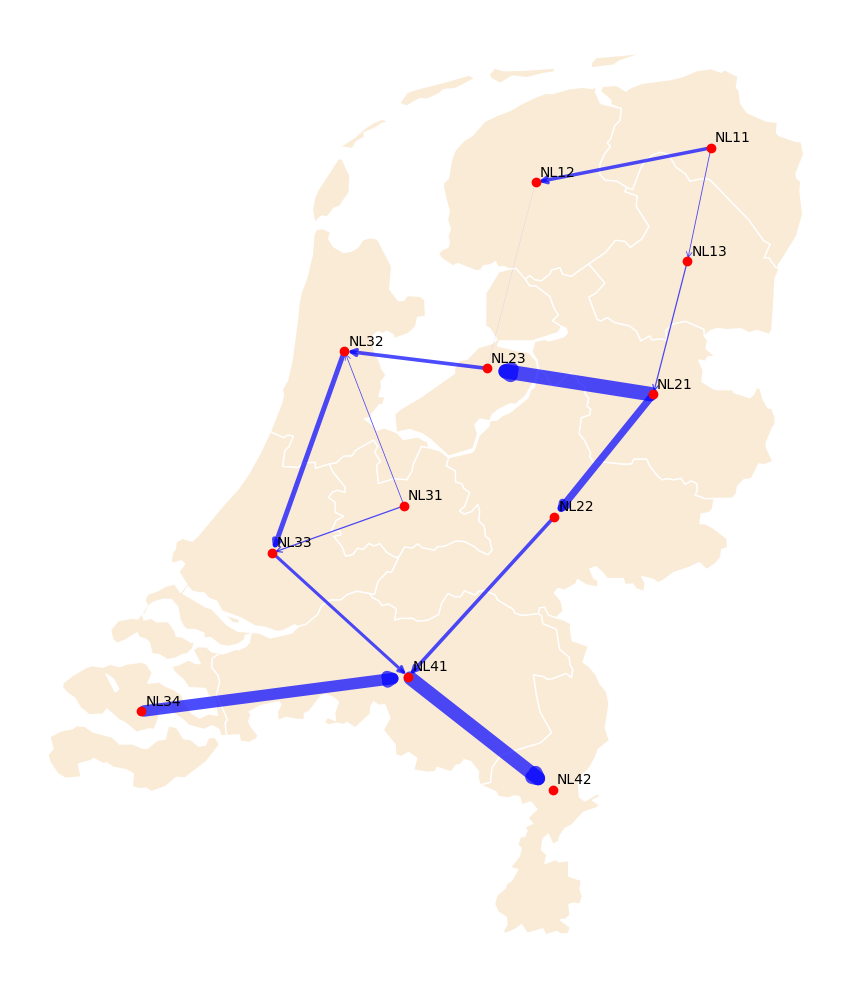

In [43]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

# Load the geojson file for the base map
geojson_file = "timeseries_data/demand/historic_2023/NUTS_RG_20M_2024_3035_modified.geojson"
gdf_base = gpd.read_file(geojson_file)

# Maximum net_flow for scaling
max_net_flow = result["net_flow"].abs().max()

# Extract node coordinates from the model
node_coords = pd.DataFrame(
    model.inputs['loc_coordinates'].values.T, 
    index=model.inputs['locs'].values, 
    columns=['lon', 'lat']
)

# Swap 'lat' and 'lon' to correct the coordinates
node_coords = node_coords.rename(columns={"lat": "lon", "lon": "lat"})[["lat", "lon"]]

# Exclude NL and NO nodes (adjust as needed)
excluded_nodes = ["NL","UK","NO","DK","DE","BE"]
node_coords = node_coords[~node_coords.index.isin(excluded_nodes)]

# Build a list of (start_loc, end_loc, flow_value)
parsed_links = []
for _, row in results.iterrows():
    loc_a, loc_b = row["pair"]  
    net_flow = row["net_flow"]

    # Skip links involving excluded nodes
    if (loc_a in excluded_nodes) or (loc_b in excluded_nodes):
        continue

    # If net_flow > 0, direction = loc_b -> loc_a
    if net_flow > 0:
        parsed_links.append((loc_a, loc_b, net_flow))
    # If net_flow < 0, direction = loc_a -> loc_b (store it as a positive number for plotting)
    elif net_flow < 0:
        parsed_links.append((loc_a, loc_b, net_flow))
    # If net_flow == 0, we can still store (loc_b, loc_a, 0) for the thin black line
    else:
        parsed_links.append((loc_a, loc_b, 0))

# Create the plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the base map
gdf_base.plot(ax=ax, facecolor='antiquewhite', edgecolor='white', zorder=1)

# Plot all nodes (excluding the excluded nodes)
ax.scatter(node_coords['lon'], node_coords['lat'], color='red', zorder=10)

# Plot transmission flows
for flow_start, flow_end, net_flow in parsed_links:
    start_coords = node_coords.loc[flow_start]
    end_coords   = node_coords.loc[flow_end]
    
    # If flow == 0, plot a thin black line with no arrow
    if net_flow == 0:
        ax.plot(
            [start_coords['lon'], end_coords['lon']], 
            [start_coords['lat'], end_coords['lat']], 
            color='black', lw=0.5, alpha=0.5, zorder=4
        )
    else:
        flow_abs = abs(net_flow)
        # Scale line thickness by fraction of max net_flow
        linewidth = (flow_abs / max_net_flow) * 10  
        ax.annotate(
            "",
            xy=(end_coords['lon'], end_coords['lat']),    # Arrow tip
            xytext=(start_coords['lon'], start_coords['lat']),  # Arrow base
            arrowprops=dict(arrowstyle="->", color='blue', lw=linewidth, alpha=0.7),
            zorder=5
        )

# Add node labels
for loc, coord in node_coords.iterrows():
    ax.text(coord['lon'] + 0.02, coord['lat'] + 0.02, loc, fontsize=10, ha='left', zorder=15)

# Finalize the figure
ax.axis('off')
plt.tight_layout()
plt.savefig("flow_during_max_res_day_tennet.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [24]:
dfgas=df = pd.read_csv("gas_carrier_prod_pypsa.csv")
dfgas2=df = pd.read_csv("gas_carrier_prod_tennet.csv")
filtered_dfgas = dfgas.loc[(dfgas['timesteps'] == "2050-12-15 10:00:00")]
filtered_dfgas2 = dfgas2.loc[(dfgas2['timesteps'] == "2050-12-15 10:00:00")]

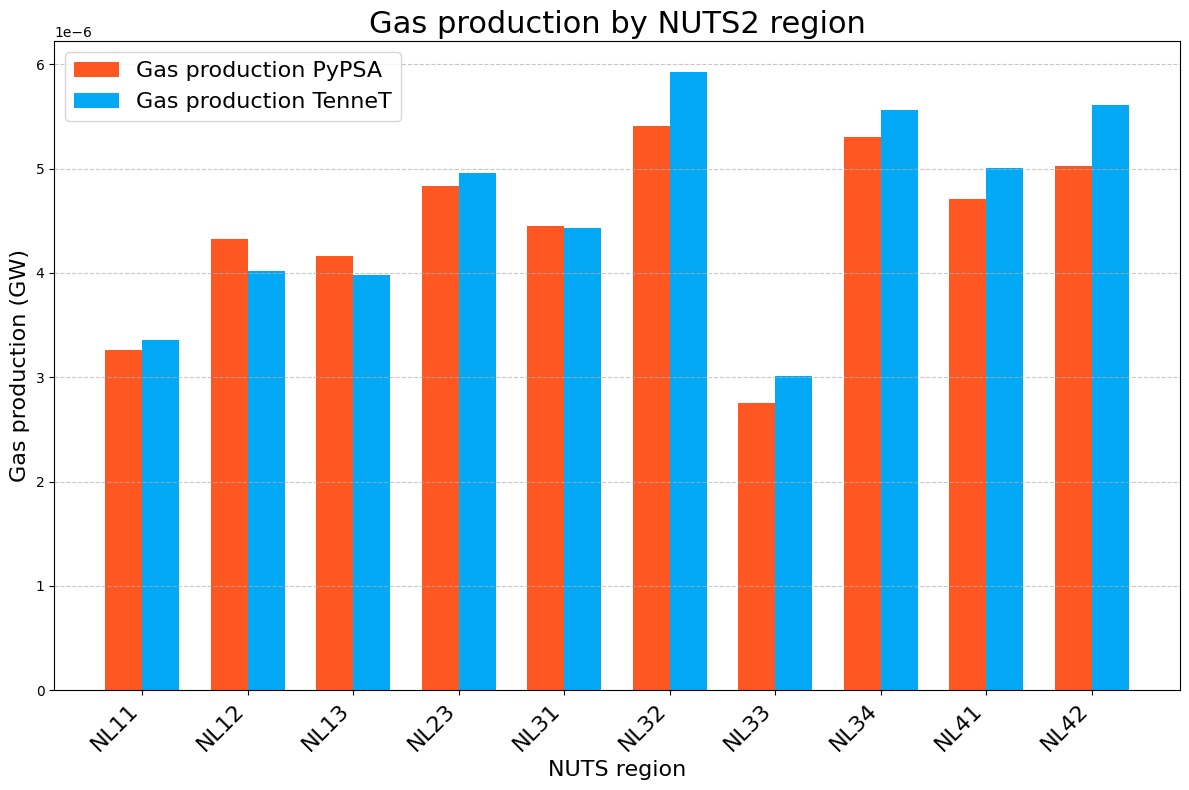

loc_tech_carriers_prod
NL11::pp_ccgt_gas::electricity    0.000003
NL12::pp_ccgt_gas::electricity    0.000004
NL13::pp_ccgt_gas::electricity    0.000004
NL23::pp_ccgt_gas::electricity    0.000005
NL31::pp_ccgt_gas::electricity    0.000004
NL32::pp_ccgt_gas::electricity    0.000006
NL33::pp_ccgt_gas::electricity    0.000003
NL34::pp_ccgt_gas::electricity    0.000006
NL41::pp_ccgt_gas::electricity    0.000005
NL42::pp_ccgt_gas::electricity    0.000006
Name: carrier_prod, dtype: float64

In [25]:
# Group and sum the carrier_prod values for both datasets
grouped_dfgas = filtered_dfgas.groupby("loc_tech_carriers_prod")["carrier_prod"].sum()
grouped_dfgas2 = filtered_dfgas2.groupby("loc_tech_carriers_prod")["carrier_prod"].sum()

# Union of all loc_tech_carriers_prod across both datasets
all_techs = grouped_dfgas.index.union(grouped_dfgas2.index)
grouped_dfgas = grouped_dfgas.reindex(all_techs, fill_value=0)
grouped_dfgas2 = grouped_dfgas2.reindex(all_techs, fill_value=0)

# Filter out loc_tech_carriers_prod where both datasets have carrier_prod <= 0
mask = (grouped_dfgas > 0) | (grouped_dfgas2 > 0)
filtered_techs = all_techs[mask]
grouped_dfgas = grouped_dfgas[filtered_techs]
grouped_dfgas2 = grouped_dfgas2[filtered_techs]

# Extract only the "loc" part of loc_tech_carriers_prod for x-axis labels
loc_labels = [tech.split("::")[0] for tech in filtered_techs]

# Create the bar chart
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(filtered_techs))

# Bar width
bar_width = 0.35

# Bar for PyPSA dataset
ax.bar(
    x - bar_width / 2,  # Adjust position
    grouped_dfgas,
    width=bar_width,
    label="Gas production PyPSA",
    color="#FF5722"  # Orange
)

# Bar for TenneT dataset
ax.bar(
    x + bar_width / 2,  # Adjust position
    grouped_dfgas2,
    width=bar_width,
    label="Gas production TenneT",
    color="#03A9F4"  # Blue
)

# Add title and labels
ax.set_title("Gas production by NUTS2 region", fontsize=22)
ax.set_xlabel("NUTS region", fontsize=16)
ax.set_ylabel("Gas production (GW)", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(loc_labels, rotation=45, ha="right", fontsize=16)
ax.legend(fontsize=16)
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("historic gas generation max res.pdf", dpi=300, bbox_inches="tight")
plt.show()
grouped_dfgas2
